## <span style="color:blue"> Lezione 11 </span>



In [2]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.mplot3d import Axes3D
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Input


parent_folder="l_10_all_es/"

2026-05-23 17:40:37.697261: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 17:40:37.933305: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### <span style="color:DodgerBlue"> Esercizio 11.2 </span>



Lo scopo dell'esercizio è di effettuare un fit del polinomio $f(x)=x^3-2x^2 -3x+4$ per $x \in [-1,1]$ (la cui implementazione in codice è riportata nella cella sottostante),  tramite l'utilizzo di un modello di rete neurale. 

In [3]:

def f(x):
    return 4-3*x-2*x**2+3*x**3

I parametri della rete neurale sono riportati nella cella sottostante: 

In [ ]:
#parametri
batch_size=20 
N_epoch=50
N_neurons=10
N_train=5000
N_val=500
activation_function='elu'

I dati per l'addestramento ($x_\mathrm{train},y_\mathrm{train}$) e la validazione ($x_\mathrm{valid},y_\mathrm{valid}$) del modello vengono generati nella seguente maniera:
1. Si estrae $x$ nell'intervallo $[-1,1]$ con probabilità uniforme 
2. Si calcola $f(x)$
3. Si estrae $y$ da una gaussiana centrata in $f(x)$ e con deviazione standard $\sigma=0.2$ 

In [ ]:
#Generazione dati
np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train).reshape(-1,1)
x_valid = np.random.uniform(-1, 1, N_val).reshape(-1,1)
x_valid.sort()
sigma = 0.2
y_train = np.random.normal(f(x_train), sigma)
y_valid = np.random.normal(f(x_valid), sigma)



Nelle celle sottostanti viene costruito e addestrato il modello.

In [6]:

model = keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(N_neurons,activation=activation_function))
model.add(Dense(N_neurons,activation=activation_function))
model.add(Dense(1))

model.compile(optimizer='sgd', loss='mse', metrics=['mse'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(x=x_train, y=y_train, 
          batch_size=batch_size, epochs=N_epoch, 
          validation_data=(x_valid, y_valid),
          verbose=False#inserito per "alleggerire" il notebook
          )

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0452 - mse: 0.0452 
Test loss: 0.04522888734936714


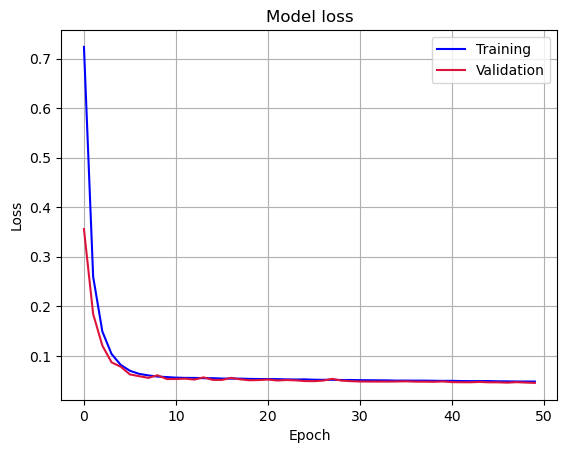

In [ ]:

score = model.evaluate(x_valid, y_valid, batch_size=batch_size, verbose=1)
print('Test loss:', score[0])
plt.plot(history.history['loss'],color="blue")
plt.plot(history.history['val_loss'],color="crimson")
plt.grid()
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')
plt.show()



Nella cella sottostante, invece, si vuole andare a valutare la capacità predittiva del modello per $200$ valori di $x$, distribuite a spaziatura costante in un intervallo per tre diversi intervalli: $[-1,1], [-1.5,0.5], [1,3]$. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


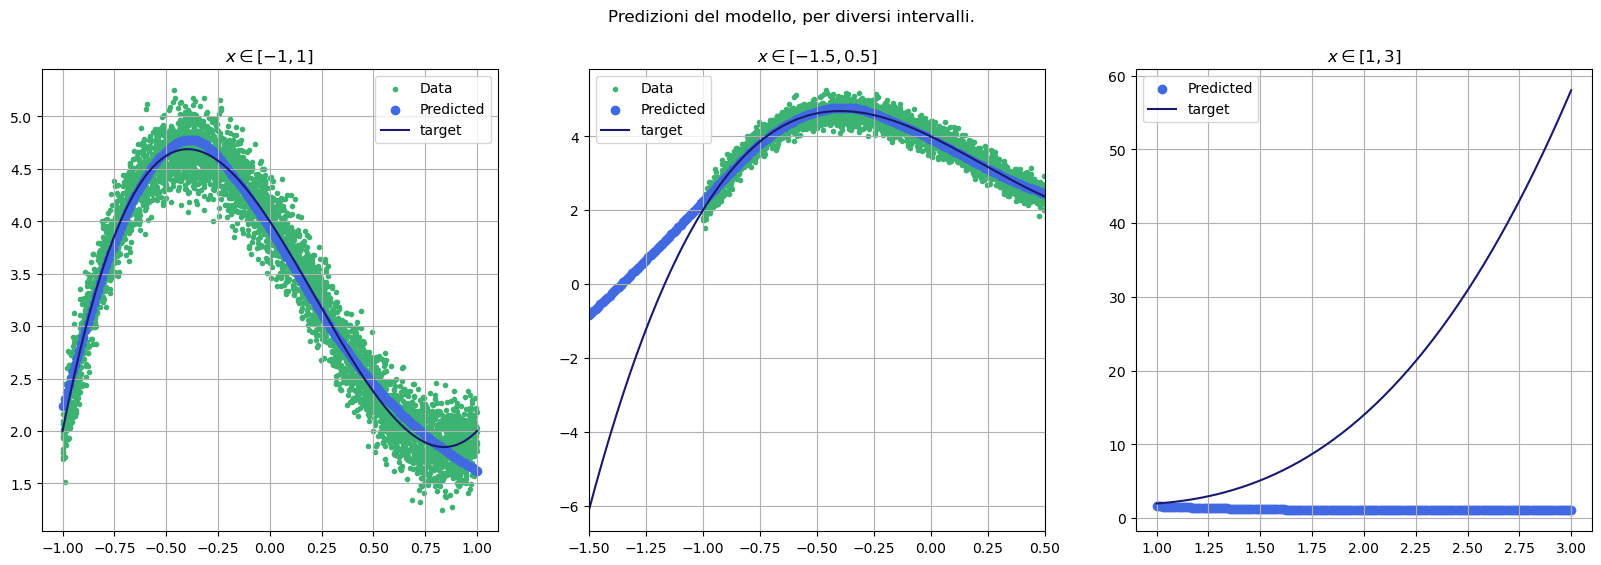

In [9]:

fig,axs=plt.subplots(1,3,figsize=[20,6])

x_test=np.linspace(-1,1,200).reshape(-1,1)



y_predicted = model.predict(x_test, batch_size=200)


axs[0].scatter(x_train,y_train,marker=".",label="Data",color="mediumseagreen")

axs[0].scatter(x_test,y_predicted,color="royalblue",label="Predicted")
axs[0].plot(x_test,f(x_test),color="midnightblue",label="target")

axs[0].grid()

axs[0].legend()

x_test=np.linspace(-1.5,0.5,200).reshape(-1,1)

y_predicted = model.predict(x_test, batch_size=200)

axs[1].scatter(x_train,y_train,marker=".",label="Data",color="mediumseagreen")

axs[1].scatter(x_test,y_predicted,color="royalblue",label="Predicted")
axs[1].plot(x_test,f(x_test),color="midnightblue",label="target")

axs[1].grid()
axs[1].set_xlim([-1.5,0.5])

axs[1].legend()

x_test=np.linspace(1,3,200).reshape(-1,1)

y_predicted = model.predict(x_test, batch_size=200)


axs[2].scatter(x_test,y_predicted.T,color="royalblue",label="Predicted")
axs[2].plot(x_test,f(x_test),color="midnightblue",label="target")

axs[2].grid()

axs[2].legend()



fig.suptitle("Predizioni del modello, per diversi intervalli.")
axs[0].set_title(r"$x \in [-1,1]$")
axs[1].set_title(r"$x \in [-1.5,0.5]$")
axs[2].set_title(r"$x \in [1,3]$");




La figura mostra come il potere predittivo del modello si esaurisca per $x$ al di fuori dai confini dell'intervallo dei dati usati per il training. 

### <span style="color:DodgerBlue"> Esercizio 11.3 </span>



Sempre tramite una rete neurale, si vuole ora effettuare un fit della funzione $g(x,y) =\sin(x^2+y^2) \coloneq \mathbb{R}^2 \to \mathbb{R}$, per $x,y \in [-3/2,3/2]$. Il codice che implementa la funzione è riportato sotto. 

In [10]:
def g(x,y): 
    return np.sin(x**2+y**2)

In [ ]:
#parametri
batch_size2=20
N_epoch2=70
N_neurons2=20
N_train2=10000
N_val2=2000
activation_function2='elu'

In [12]:
#Generazione dati
np.random.seed(0)
x_train2 = np.column_stack([ np.random.uniform(-3/2, 3/2, N_train2), np.random.uniform(-3/2, 3/2, N_train2)])
x_valid2 =np.column_stack([ np.random.uniform(-3/2, 3/2, N_val2), np.random.uniform(-3/2, 3/2, N_val2)])

sigma2 = 0.2
y_train2 = np.random.normal(g(x_train2[:,0],x_train2[:,1]), sigma2) 
y_valid2 = np.random.normal(g(x_valid2[:,0],x_valid2[:,1]), sigma2) 


In [13]:

model2 = keras.Sequential()
model2.add(Input(shape=(2,)))
model2.add(Dense(5*N_neurons2,activation=activation_function2))
model2.add(Dense(4*N_neurons2,activation=activation_function2))
model2.add(Dense(3*N_neurons2,activation=activation_function2))
model2.add(Dense(2*N_neurons2,activation=activation_function2))
model2.add(Dense(N_neurons2,activation=activation_function2))
model2.add(Dense(1))

model2.compile(optimizer='sgd', loss='mse', metrics=['mse'])
model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 60)             │         4,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 40)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,521 (64.54 KB)

 Trainable params: 16,521 (64.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history2 = model2.fit(x=x_train2, y=y_train2, 
          batch_size=batch_size2, epochs=N_epoch2, 
          validation_data=(x_valid2, y_valid2),verbose=False)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0437 - mse: 0.0437
Test loss: 0.04374402388930321


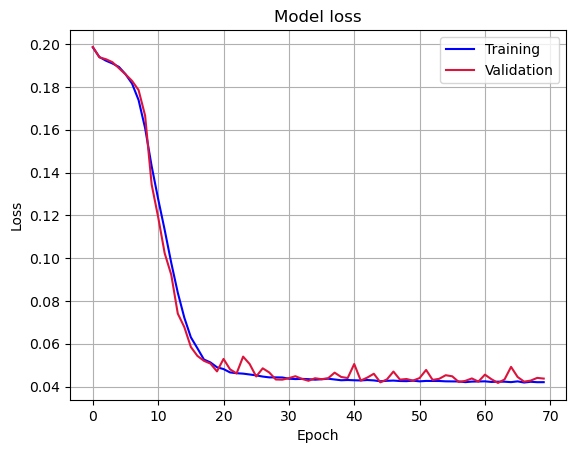

In [15]:

score2 = model2.evaluate(x_valid2, y_valid2, batch_size=batch_size2, verbose=1)
print('Test loss:', score2[0])
plt.plot(history2.history['loss'],color="blue")
plt.plot(history2.history['val_loss'],color="crimson")
plt.grid()
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')
plt.show()



79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


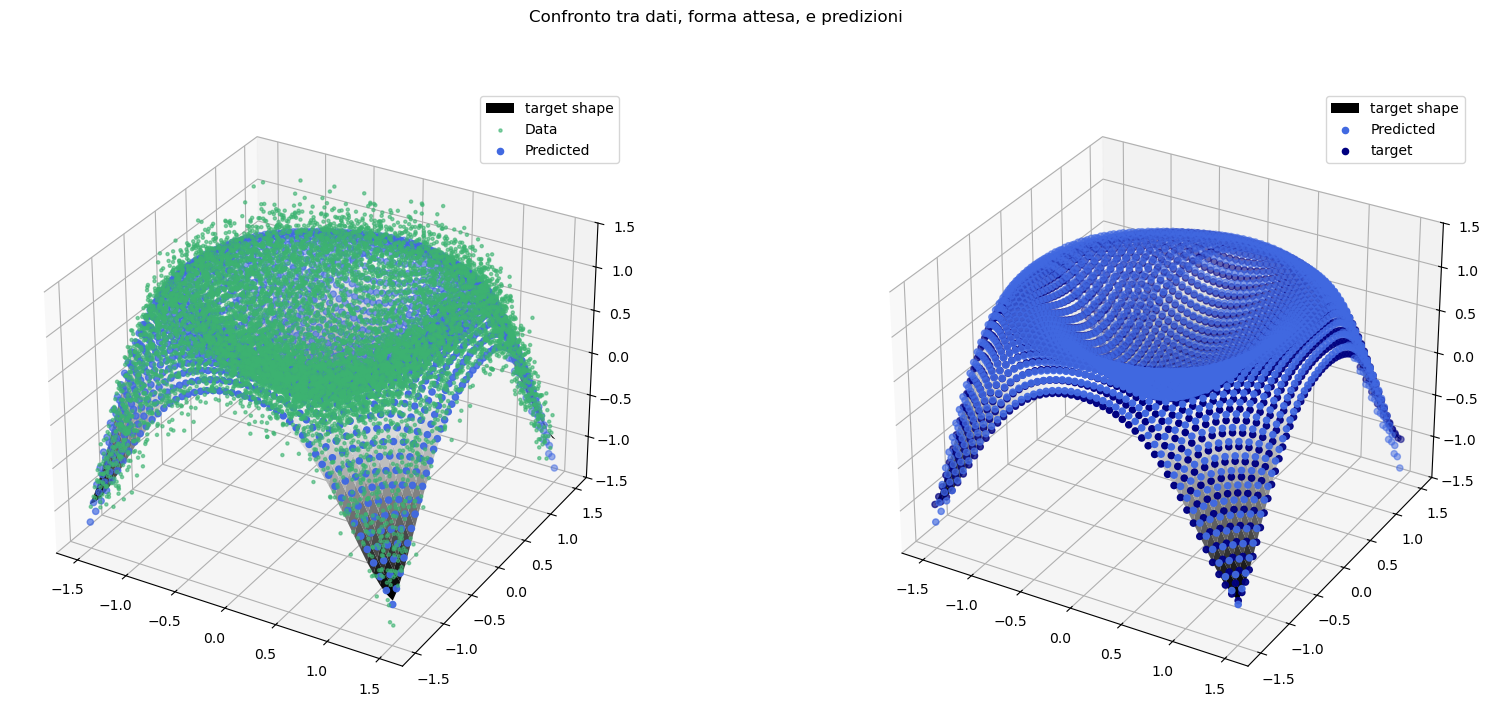

In [23]:

fig = plt.figure(figsize=[20,8])

x=np.linspace(-3/2,3/2,50)
y=np.linspace(-3/2,3/2,50)

xx,yy=np.meshgrid(x,y)
x_test_grid=np.column_stack([xx.ravel(),yy.ravel()])

y_predicted2=model2.predict(x_test_grid)


ax1 = fig.add_subplot(121, projection='3d')  
ax2 = fig.add_subplot(122, projection='3d') 

ax1.plot_surface(xx, yy, g(xx,yy), cmap='Greys_r',label="target shape")
ax1.scatter(x_train2[:,0],x_train2[:,1],y_train2,color="mediumseagreen",marker=".",label="Data",alpha=0.6)
ax1.scatter(x_test_grid[:,0],x_test_grid[:,1],y_predicted2[:,0],color="royalblue",label="Predicted");

ax1.legend()
ax1.set_zlim3d([-1.5,1.5])

ax2.plot_surface(xx, yy, g(xx,yy), cmap='Greys_r',label="target shape")
ax2.scatter(x_test_grid[:,0],x_test_grid[:,1],y_predicted2[:,0],color="royalblue",label="Predicted")
ax2.scatter(x_test_grid[:,0],x_test_grid[:,1],g(x_test_grid[:,0],x_test_grid[:,1]),color="navy",label="target")

#ax2.plot_surface(xx,yy,y_predicted.reshape(xx.shape),cmap="viridis")
ax2.set_zlim3d([-1.5,1.5])
ax2.legend()
fig.suptitle("Confronto tra dati, forma attesa, e predizioni");
